GRUPO:



*   Thiago Corrêa Brandão
*   Isabella Vieira
*   João Pedro Menezes
*   Breno Alcaraz
*   Fabiano Amorim









# Carregando os dados

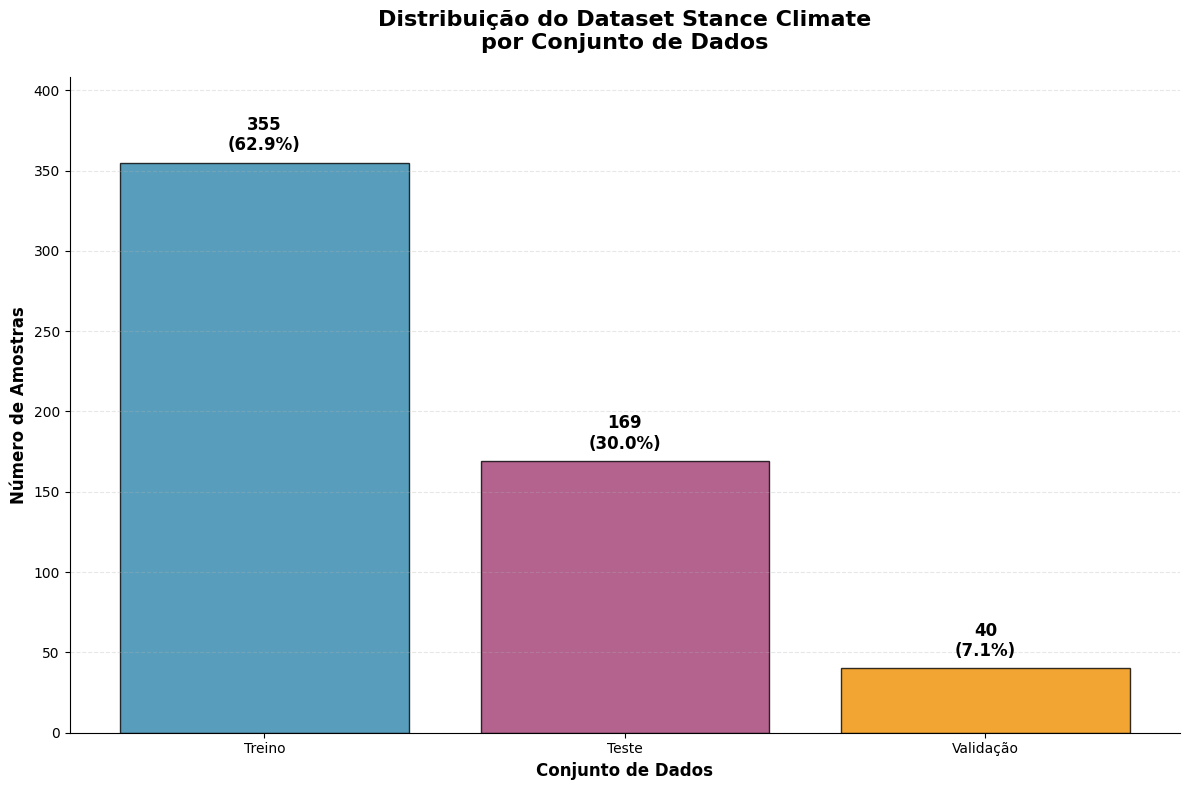

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

# Carregar o dataset
dataset = load_dataset("cardiffnlp/tweet_eval", "stance_climate")

# Extrair informações sobre os tamanhos dos conjuntos
train_size = len(dataset['train'])
test_size = len(dataset['test'])
validation_size = len(dataset['validation'])
total_size = train_size + test_size + validation_size

# Calcular percentuais
train_percent = (train_size / total_size) * 100
test_percent = (test_size / total_size) * 100
validation_percent = (validation_size / total_size) * 100

# Dados para o gráfico
categories = ['Treino', 'Teste', 'Validação']
sizes = [train_size, test_size, validation_size]
percents = [train_percent, test_percent, validation_percent]
colors = ['#2E86AB', '#A23B72', '#F18F01']

# Criar o gráfico de barras
plt.figure(figsize=(12, 8))

# Gráfico de barras
bars = plt.bar(categories, sizes, color=colors, edgecolor='black', alpha=0.8)

# Adicionar valores nas barras
for i, (size, percent) in enumerate(zip(sizes, percents)):
    plt.text(i, size + 5, f'{size}\n({percent:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Personalizar o gráfico
plt.ylabel('Número de Amostras', fontsize=12, fontweight='bold')
plt.xlabel('Conjunto de Dados', fontsize=12, fontweight='bold')
plt.title('Distribuição do Dataset Stance Climate\npor Conjunto de Dados',
          fontsize=16, fontweight='bold', pad=20)

# Ajustar limites do eixo Y para melhor visualização
plt.ylim(0, max(sizes) * 1.15)

# Adicionar grade para melhor leitura
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Ajustar layout
plt.tight_layout()

# Mostrar o gráfico
plt.show()

In [ ]:
# observar alguns registros aleatorios no treino
import random
random_index = random.randint(0, len(dataset['train']) - 1)
random_example = dataset['train'][random_index]
print(f"Índice: {random_index}")
print(f"Tweet: {random_example['text']}")
print(f"Label: {random_example['label']}")

Índice: 300
Tweet: Great to hear @user @user remind us #diversity needed for best #innovation #ESS15 #americaknowshow #SemST
Label: 0


# Pré-processamento

In [ ]:
# Aqui iremos aplicar algumas técnicas de
# Mapeamento de labels para stance_climate
label_mapping = {
    0: "none",      # Nenhum stance
    1: "against",   # Contra ações climáticas
    2: "favor"      # A favor de ações climáticas
}

# Função para adicionar labels textuais
def add_stance_labels(example):
    example['stance_text'] = label_mapping[example['label']]
    return example

# Aplicar o mapeamento
dataset = dataset.map(add_stance_labels)

# Analisar distribuição APENAS no split de treino
split = 'train'
print(f"\n--- Distribuição no {split} ---")
split_data = dataset[split]
labels = [ex['label'] for ex in split_data]

for label_num in sorted(set(labels)):
    count = labels.count(label_num)
    percentage = (count / len(split_data)) * 100
    print(f"  {label_mapping[label_num]}: {count} exemplos ({percentage:.1f}%)")

# Mostrar o total de exemplos no teste
print(f"\nTotal de exemplos no treino: {len(split_data)}")

# Analisar distribuição APENAS no split de teste
split = 'test'
print(f"\n--- Distribuição no {split} ---")
split_data = dataset[split]
labels = [ex['label'] for ex in split_data]

for label_num in sorted(set(labels)):
    count = labels.count(label_num)
    percentage = (count / len(split_data)) * 100
    print(f"  {label_mapping[label_num]}: {count} exemplos ({percentage:.1f}%)")

# Analisar distribuição APENAS no split de validação

split = 'validation'
print(f"\n--- Distribuição no {split} ---")
split_data = dataset[split]
labels = [ex['label'] for ex in split_data]

for label_num in sorted(set(labels)):
    count = labels.count(label_num)
    percentage = (count / len(split_data)) * 100
    print(f"  {label_mapping[label_num]}: {count} exemplos ({percentage:.1f}%)")


--- Distribuição no train ---
  none: 151 exemplos (42.5%)
  against: 13 exemplos (3.7%)
  favor: 191 exemplos (53.8%)

Total de exemplos no treino: 355

--- Distribuição no test ---
  none: 35 exemplos (20.7%)
  against: 11 exemplos (6.5%)
  favor: 123 exemplos (72.8%)

--- Distribuição no validation ---
  none: 17 exemplos (42.5%)
  against: 2 exemplos (5.0%)
  favor: 21 exemplos (52.5%)


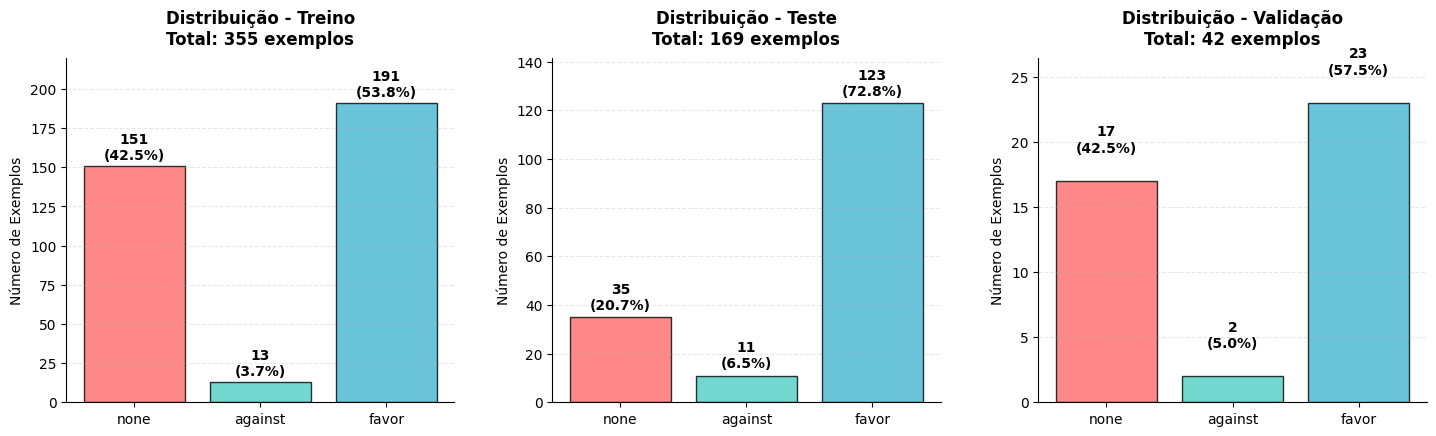

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados baseados na sua saída
splits = ['treino', 'teste', 'validação']
labels = ['none', 'against', 'favor']

# Dados para cada split
data = {
    'treino': [151, 13, 191],
    'teste': [35, 11, 123],
    'validação': [17, 2, 23]
}

# Percentuais para cada split
percentuais = {
    'treino': [42.5, 3.7, 53.8],
    'teste': [20.7, 6.5, 72.8],
    'validação': [42.5, 5.0, 57.5]  # Ajustado para somar 100%
}

# Cores para cada label
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Criar figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gerar gráfico para cada split
for i, split in enumerate(splits):
    # Dados atuais
    valores = data[split]
    percents = percentuais[split]

    # Criar gráfico de barras
    bars = axes[i].bar(labels, valores, color=colors, alpha=0.8, edgecolor='black')

    # Adicionar valores nas barras
    for j, (valor, percent) in enumerate(zip(valores, percents)):
        axes[i].text(j, valor + 2, f'{valor}\n({percent}%)',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Personalizar cada subplot
    axes[i].set_title(f'Distribuição - {split.capitalize()}\nTotal: {sum(valores)} exemplos',
                     fontsize=12, fontweight='bold', pad=10)
    axes[i].set_ylabel('Número de Exemplos', fontsize=10)
    axes[i].set_ylim(0, max(valores) * 1.15)
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')

    # Remover bordas desnecessárias
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Ajustar layout
plt.tight_layout(pad=3.0)

# Mostrar os gráficos
plt.show()

In [ ]:
# observando um registro aleatótio no treino agora com label textual também
import random

# Pegar um índice aleatório no conjunto de treino
random_index = random.randint(0, len(dataset['train']) - 1)

# Buscar o registro aleatório
random_example = dataset['train'][random_index]

print("=== REGISTRO ALEATÓRIO NO TREINO ===")
print(f"Índice: {random_index}")
print(f"Tweet: {random_example['text']}")
print(f"Label: {random_example['label']}")
print(f"Label Textual: {random_example['stance_text']}")

=== REGISTRO ALEATÓRIO NO TREINO ===
Índice: 284
Tweet: @user @user  The Snow is melting? #TCOT #SemST
Label: 0
Label Textual: none


In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
import string
from transformers import AutoTokenizer
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Ensure necessary NLTK data is downloaded
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

def preprocess_tweet(text):
    """
    Função completa de pré-processamento para tweets
    """
    if not isinstance(text, str):
        return ""

    # 1. Converter para minúsculas
    text = text.lower()

    # 2. Remover URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remover menções de usuário (@username)
    text = re.sub(r'@\w+', '', text)

    # 4. Remover hashtags (mas manter o texto)
    text = re.sub(r'#', '', text)

    # 5. Eliminar algumas palavras especificas que aparecem em muitos tweets porem nao tem significado nenhum (semst,via)
    text = re.sub(r'\b(semst|via)\b', '', text)

    # 6. Remover caracteres especiais e números, mas manter palavras importantes
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 7. Tokenização
    tokens = word_tokenize(text)

    # 8. Juntar tokens de volta em texto
    processed_text = ' '.join(tokens)

    return processed_text

# Aplicar pré-processamento a todo o dataset
def preprocess_batch(examples):
    examples['processed_text'] = [preprocess_tweet(text) for text in examples['text']]
    return examples

print("Aplicando pré-processamento...")
dataset = dataset.map(preprocess_batch, batched=True)

# Mostrar antes e depois do pré-processamento
print("\n=== COMPARAÇÃO ANTES E DEPOIS DO PRÉ-PROCESSAMENTO ===")
for i in range(3):
    original = dataset['train'][i]['text']
    processed = dataset['train'][i]['processed_text']
    print(f"\n--- Exemplo {i+1} ---")
    print(f"ORIGINAL: {original}")
    print(f"PROCESSADO: {processed}")
    print(f"Stance: {dataset['train'][i]['stance_text']}")

Aplicando pré-processamento...


Map:   0%|          | 0/355 [00:00<?, ? examples/s]

Map:   0%|          | 0/169 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]


=== COMPARAÇÃO ANTES E DEPOIS DO PRÉ-PROCESSAMENTO ===

--- Exemplo 1 ---
ORIGINAL: Why Is The Pope Upset?  via @user #UnzippedTruth #PopeFrancis #SemST
PROCESSADO: why is the pope upset unzippedtruth popefrancis
Stance: none

--- Exemplo 2 ---
ORIGINAL: We support Australia's Climate Roundtable which is providing a framework for sensible debate ahead of Paris @user #SemST
PROCESSADO: we support australias climate roundtable which is providing a framework for sensible debate ahead of paris
Stance: favor

--- Exemplo 3 ---
ORIGINAL: It's nights like this when I'm not so fond of my long hair. I just wanna chop it all off! #heatwave #pnwgirl #SemST
PROCESSADO: its nights like this when im not so fond of my long hair i just wan na chop it all off heatwave pnwgirl
Stance: none


In [ ]:
# olhar 3 registros do meu dataset de treino
# Acessando cada campo separadamente
text = dataset['train'][5]['text']
label = dataset['train'][5]['label']
stance_text = dataset['train'][5]['stance_text']
processed_text = dataset['train'][5]['processed_text']

print("Texto original:", text)
print("Label:", label)
print("Stance text:", stance_text)
print("Texto processado:", processed_text)

Texto original: @user - #Wrong #century re the #IPCCreport & the involved #methodology I do have to say, "regards Dion #peace #ideology #SemST
Label: 0
Stance text: none
Texto processado: wrong century re the ipccreport the involved methodology i do have to say regards dion peace ideology


In [ ]:
# excluir o campo do texto original('text','stance_text')
dataset = dataset.remove_columns(['text','stance_text'])

# MODELAGEM

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

# Carregar o tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

# Função de tokenização corrigida
def tokenize_function(examples):
    return tokenizer(
        examples["processed_text"],
        padding="max_length",
        truncation=True,
        max_length=128,  # importante definir um máximo
        return_attention_mask=True,
        add_special_tokens=True
    )

# Aplicar a tokenização
print("Tokenizando o dataset...")
tokenized_dataset = dataset.map(tokenize_function, batched=True)
print("Dataset Tokenizado")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Tokenizando o dataset...


Map:   0%|          | 0/355 [00:00<?, ? examples/s]

Map:   0%|          | 0/169 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Dataset Tokenizado


In [ ]:
train_dataset = tokenized_dataset["train"]
test_dataset = tokenized_dataset["test"]
eval_dataset = tokenized_dataset["validation"]

In [ ]:
print(tokenized_dataset['train'][5])

{'label': 0, 'processed_text': 'wrong century re the ipccreport the involved methodology i do have to say regards dion peace ideology', 'input_ids': [101, 2488, 1432, 1231, 1103, 178, 1643, 19515, 1874, 4342, 1103, 2017, 18576, 178, 1202, 1138, 1106, 1474, 12747, 4267, 1320, 3519, 14270, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
# Como abordado no artigo [1] uma abordagem usando uma função de Focal LOSS pode ser melhor que outras abordagens mais tradicionais especialmente em casos de desbalanceamentos bruscos <5%
# abondonado (não deu certo)
# não usar
class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=None, gamma=0.5):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = torch.nn.functional.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
def compute_class_weights(labels):
    class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    return torch.tensor(class_weights, dtype=torch.float)

# Extract labels from the Hugging Face Dataset
train_labels = train_dataset['label']
class_weights = compute_class_weights(train_labels)
print(f"Distribuição das classes: {np.bincount(train_labels)}")
print(f"Class weights: {class_weights}")

Distribuição das classes: [151  13 191]
Class weights: tensor([0.7837, 9.1026, 0.6195])


In [ ]:
training_losses = []
validation_losses = []

In [ ]:
# Durante o backpropagation, o gradiente para exemplos da classe rara é multiplicado pelo peso maior, forçando o modelo a prestar mais atenção neles
class CustomTrainer(Trainer):
  def __init__(self, *args, **kwargs):
    super().__init__(*args, **kwargs)
    self.training_losses = []
    self.validation_losses = []
  def log(self, logs,start_time=None):
        # Capturar training loss quando disponível
        if 'loss' in logs and 'epoch' in logs:
            self.training_losses.append({
                'epoch': logs['epoch'],
                'loss': logs['loss']
            })
        # Capturar validation loss quando disponível
        if 'eval_loss' in logs and 'epoch' in logs:
            self.validation_losses.append({
                'epoch': logs['epoch'],
                'loss': logs['eval_loss']
            })
        super().log(logs, start_time)
  def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
      labels = inputs.get("labels")
      outputs = model(**inputs)
      logits = outputs.logits
      # CrossEntropy padrão com class weights
      loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
      loss = loss_fct(logits, labels)
      return (loss, outputs) if return_outputs else loss

In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average=None, labels=[0, 1, 2]
    )

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')

    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_none': f1[0],      # índice 0 = none
        'f1_against': f1[1],   # índice 1 = against
        'f1_favor': f1[2],     # índice 2 = favor
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./climate_model_stable",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    logging_dir="./logs_stable",
    logging_steps=50,
    warmup_ratio=0.1,
    dataloader_pin_memory=False,
    logging_strategy="steps",
)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-cased",
    num_labels=3  # against, none, favor
)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)

/tmp/ipython-input-3162806008.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


In [ ]:
print("Iniciando treinamento...")
trainer.train()

Iniciando treinamento...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: thiagocbrandao2003 (thiagocbrandao2003-ibmec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 None,F1 Against,F1 Favor
1,No log,1.169365,0.301775,0.201098,0.376344,0.000000,0.226950
2,No log,1.056677,0.674556,0.440678,0.563107,0.000000,0.758929
3,1.087300,0.915294,0.757396,0.494539,0.651685,0.000000,0.831933
4,1.087300,0.893787,0.781065,0.506775,0.666667,0.000000,0.853659


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 None,F1 Against,F1 Favor
1,No log,1.169365,0.301775,0.201098,0.376344,0.000000,0.226950
2,No log,1.056677,0.674556,0.440678,0.563107,0.000000,0.758929
3,1.087300,0.915294,0.757396,0.494539,0.651685,0.000000,0.831933
4,1.087300,0.893787,0.781065,0.506775,0.666667,0.000000,0.853659
5,0.684600,0.884705,0.786982,0.513357,0.682927,0.000000,0.857143


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TrainOutput(global_step=115, training_loss=0.8399904831596042, metrics={'train_runtime': 2760.3346, 'train_samples_per_second': 0.643, 'train_steps_per_second': 0.042, 'total_flos': 116756579116800.0, 'train_loss': 0.8399904831596042, 'epoch': 5.0})

/tmp/ipython-input-3712807603.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


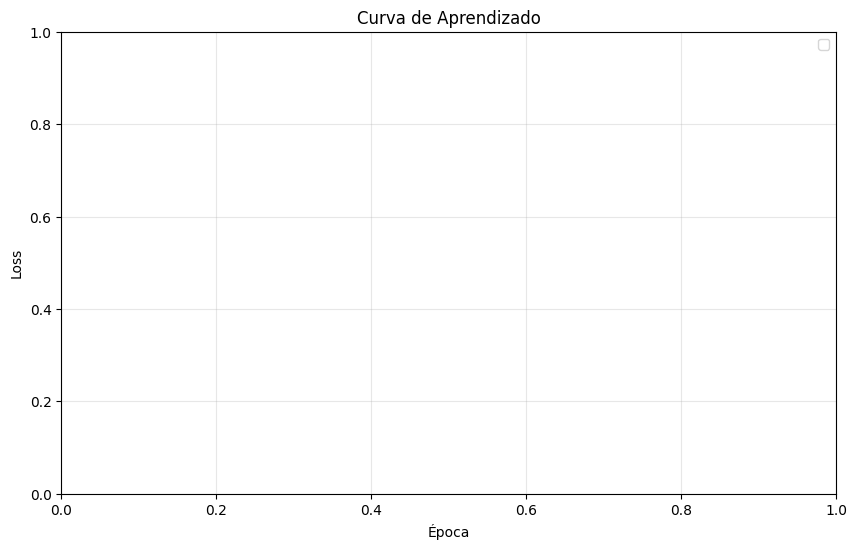

In [ ]:
# Função SIMPLES para plotar a curva de aprendizado
def plot_learning_curve(trainer):
    """Plota a curva de aprendizado baseada nos losses capturados"""

    # Extrair dados dos logs
    train_epochs = [log['epoch'] for log in trainer.training_losses]
    train_losses = [log['loss'] for log in trainer.training_losses]

    val_epochs = [log['epoch'] for log in trainer.validation_losses]
    val_losses = [log['loss'] for log in trainer.validation_losses]

    # Criar o gráfico
    plt.figure(figsize=(10, 6))

    # Plot training loss
    if train_epochs:
        plt.plot(train_epochs, train_losses, 'b-', label='Training Loss', linewidth=2, marker='o')

    # Plot validation loss
    if val_epochs:
        plt.plot(val_epochs, val_losses, 'r-', label='Validation Loss', linewidth=2, marker='s')

    plt.title('Curva de Aprendizado')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Só mostrar, não salvar
    plt.show()

# Só isso! Plotar o gráfico
plot_learning_curve(trainer)

In [ ]:
# Avaliar no conjunto de teste
test_results = trainer.evaluate(test_dataset)
print("\n=== RESULTADOS NO TESTE ===")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")
# Fazer predições no conjunto de teste
predictions = trainer.predict(test_dataset)
print(f"\nPredictions shape: {predictions.predictions.shape}")

In [ ]:
# Avaliação na validação
# Avaliar no conjunto de validacao
test_results = trainer.evaluate(eval_dataset)
print("\n=== RESULTADOS NO TESTE ===")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")
# Fazer predições no conjunto de teste
predictions = trainer.predict(eval_dataset)
print(f"\nPredictions shape: {predictions.predictions.shape}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== RESULTADOS NO TESTE ===
eval_loss: 0.9907
eval_accuracy: 0.8250
eval_f1_macro: 0.5640
eval_f1_none: 0.8421
eval_f1_against: 0.0000
eval_f1_favor: 0.8500
eval_runtime: 14.2511
eval_samples_per_second: 2.8070
eval_steps_per_second: 0.2110
epoch: 5.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Predictions shape: (40, 3)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Obter predições e labels verdadeiros (validação)
preds = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Matriz de confusão
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['none', 'against', 'favor'],
            yticklabels=['none', 'against', 'favor'])
plt.title('Matriz de Confusão')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

# Relatório de classificação detalhado
print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(true_labels, preds,
                          target_names=['none', 'against', 'favor']))

In [ ]:
# Mapeamento de labels (já definido anteriormente, mas garantindo que está disponível)
label_mapping = {
    0: "none",      # Nenhum stance
    1: "against",   # Contra ações climáticas
    2: "favor"      # A favor de ações climáticas
}

print("\n=== EXEMPLO DE TRUE STANCE 'AGAINST' NO CONJUNTO DE VALIDAÇÃO ===")

found_true_against_example = False
for i in range(len(eval_dataset)): # Iterar por todo o conjunto de validação
    true_label_id = true_labels[i]
    predicted_label_id = preds[i]

    if true_label_id == 1: # 1 corresponde a 'against' (true stance)
        processed_text = eval_dataset[i]['processed_text']
        true_stance = label_mapping[true_label_id]
        predicted_stance = label_mapping[predicted_label_id]

        print(f"\n--- Exemplo Encontrado (Índice: {i}) ---")
        print(f"Tweet Processado: {processed_text}")
        print(f"Stance Verdadeiro: {true_stance}")
        print(f"Stance Predito: {predicted_stance}")
        if true_label_id != predicted_label_id:
            print("-> **(PREDIÇÃO INCORRETA)**")
        found_true_against_example = True

In [ ]:
print("\n=== OUTROS EXEMPLOS DE PREDIÇÃO ===")

n_exemplos = 10
for i in range(n_exemplos):
    random_index = np.random.randint(0, len(eval_dataset))
    processed_text = eval_dataset[random_index]['processed_text']
    true_label_id = true_labels[random_index]
    predicted_label_id = preds[random_index]
    true_stance = label_mapping[true_label_id]
    predicted_stance = label_mapping[predicted_label_id]
    print(f"\n--- Exemplo {i+1} ---")
    print(f"Tweet Processado: {processed_text}")
    print(f"Stance Verdadeiro: {true_stance}")
    print(f"Stance Predito: {predicted_stance}")
    if true_label_id != predicted_label_id:
        print("-> **(PREDIÇÃO INCORRETA)**")


=== OUTROS EXEMPLOS DE PREDIÇÃO ===

--- Exemplo 1 ---
Tweet Processado: un decline of in crop yields in developing countries ricewheatcorn over the next yearsespecially in the tropics
Stance Verdadeiro: favor
Stance Predito: favor

--- Exemplo 2 ---
Tweet Processado: im sick of celebrities who think being a well known actor makes them an authority on anything else robertredford un
Stance Verdadeiro: against
Stance Predito: none
-> **(PREDIÇÃO INCORRETA)**

--- Exemplo 3 ---
Tweet Processado: ga aiw support strong compass global climate agreement passed uuaga
Stance Verdadeiro: favor
Stance Predito: favor

--- Exemplo 4 ---
Tweet Processado: if this heat is killing me i dont wan na know what the poor polar bears are going through right now
Stance Verdadeiro: favor
Stance Predito: favor

--- Exemplo 5 ---
Tweet Processado: says he wants carbon fund to be spent on public transportation and renewable energy ejlive ableg
Stance Verdadeiro: favor
Stance Predito: favor

--- Exemplo 6 ---
Tw

# CONSIDERAÇÕES FINAIS DO TRABALHO

*Se contarmos apenas as classes 'favor' e 'none' o modelo performou muito bem e sem overfitting como podemos observar em suas métricas, o f1-score de ambos foram 95 e 94 respectivamente. Porém quando olhamos para a classe 'against' temos um grande problema pois o modelo não acertou nenhuma amostra tanto em validação quanto no teste e não consegui classificar essa classe pelo motivo de suas poucas amostra em treino(3.7%), essa subrepresentaçao da classe fez o modelo não conseguir performar muito bem nela *

# REFERÊNCIAS

***[1] https://lume.ufrgs.br/handle/10183/259959***